# Content Moderation Agent with ReAct Reasoning

**Student:** Maurizio Pinto  
**Institution:** Woolf University  
**Course:** Design of Autonomous and Semi-Autonomous Agentic Workflows  

This notebook implements a content moderation agent that analyzes user-generated text, checks it against platform policies, and recommends moderation actions (approve, flag for review, or reject). The agent uses a ReAct (Reason + Act) reasoning loop with OpenAI function calling, where the LLM decides which tools to invoke, observes results, and iterates until reaching a final decision. The system includes five tools for text analysis, policy lookup, user history checking, severity assessment, and decision recording, along with safeguards for confidence thresholds, iteration limits, and escalation triggers.

## Task Definition and Scope

**Goal.** The agent's purpose is to automate the first-pass review of user-generated text on a social media platform. It analyzes content against six platform policy categories (hate speech, harassment, violence, spam, misinformation, adult content), gathers evidence through tool calls, and recommends one of three actions: approve, flag for human review, or reject.

**Scope and boundaries.** The system handles English-language text only. It does not process images, videos, links, or attachments. The agent makes recommendations — not final enforcement decisions. Content flagged as uncertain or high-severity is escalated to human moderators. The agent operates within a single moderation turn: it receives one piece of content, analyzes it, and produces one decision. It does not engage in back-and-forth conversation with users.

**Why single-agent.** Content moderation is a sequential reasoning task where each step builds on the previous one: initial analysis informs which policies to check, policy results inform severity assessment, and user history provides context for the final decision. A single agent with tool access can coordinate this workflow efficiently. A multi-agent design would add coordination overhead without clear benefit for this sequential pipeline. Multi-agent architectures are better suited to tasks requiring parallel independent subtasks (e.g., separate agents simultaneously checking text, images, and metadata), which is not the case here.

**What the agent decides.** The agent decides: (1) whether content potentially violates any policy, (2) which specific categories are relevant, (3) the severity of any violations, and (4) the recommended action given all evidence. These decisions require the agent to weigh multiple signals — text patterns, policy definitions, user history, and severity levels — which is why an agentic approach with iterative tool use is appropriate.

## Setup

In [1]:
import json
import os
import time
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from openai import OpenAI

sns.set_theme(style="whitegrid")
%matplotlib inline

print("All imports successful.")

All imports successful.


In [2]:
# Load API key from .env file
from dotenv import load_dotenv
load_dotenv()

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# Agent configuration
config = {
    "model": "gpt-4o-mini",
    "confidence_threshold": 0.7,
    "max_iterations": 15,
    "high_severity_categories": ["violence", "hate_speech"],
    "valid_actions": ["approve", "flag_for_review", "reject"],
}

print(f"Model: {config['model']}")
print(f"Confidence threshold: {config['confidence_threshold']}")
print(f"Max iterations: {config['max_iterations']}")
print(f"High-severity categories: {config['high_severity_categories']}")

Model: gpt-4o-mini
Confidence threshold: 0.7
Max iterations: 15
High-severity categories: ['violence', 'hate_speech']


## Moderation Policy Database

In [3]:
# Platform moderation policies
POLICY_DB = {
    "hate_speech": {
        "name": "Hate Speech",
        "description": "Content that attacks, demeans, or dehumanizes people based on protected characteristics including race, ethnicity, national origin, religion, sex, gender, sexual orientation, disability, or immigration status.",
        "severity_levels": {
            "low": "Questionable language that could be interpreted as biased but is ambiguous",
            "medium": "Clear use of derogatory terms or stereotyping",
            "high": "Direct attacks or dehumanizing language targeting protected groups",
            "critical": "Calls for violence or extermination of a protected group",
        },
        "action_guidance": {
            "low": "flag_for_review",
            "medium": "flag_for_review",
            "high": "reject",
            "critical": "reject",
        },
        "examples": [
            "All [group] are criminals and should be deported",
            "[Group] people are inherently inferior",
        ],
    },
    "harassment": {
        "name": "Harassment",
        "description": "Content that personally attacks, intimidates, bullies, or coordinates targeting against specific individuals.",
        "severity_levels": {
            "low": "Mild personal insult without systematic targeting",
            "medium": "Repeated or coordinated harassment of an individual",
            "high": "Doxxing, threats, or severe personal attacks",
            "critical": "Encouraging self-harm or real-world stalking",
        },
        "action_guidance": {
            "low": "flag_for_review",
            "medium": "flag_for_review",
            "high": "reject",
            "critical": "reject",
        },
        "examples": [
            "Everyone go report @user's account",
            "You're worthless and everyone hates you",
        ],
    },
    "violence": {
        "name": "Violence",
        "description": "Content that threatens physical harm, incites violence, or provides instructions for carrying out violent acts.",
        "severity_levels": {
            "low": "Vague aggressive language without specific threat",
            "medium": "Specific threats of physical harm",
            "high": "Instructions for carrying out violent acts",
            "critical": "Threats against public figures or mass violence incitement",
        },
        "action_guidance": {
            "low": "flag_for_review",
            "medium": "reject",
            "high": "reject",
            "critical": "reject",
        },
        "examples": [
            "Someone should hurt that person",
            "Here's how to make a weapon...",
        ],
    },
    "spam": {
        "name": "Spam",
        "description": "Repetitive, unsolicited, or deceptive content designed to mislead users or artificially inflate engagement.",
        "severity_levels": {
            "low": "Minor self-promotion",
            "medium": "Repetitive posting of identical content",
            "high": "Deceptive links or phishing attempts",
            "critical": "Coordinated inauthentic behavior or bot networks",
        },
        "action_guidance": {
            "low": "approve",
            "medium": "flag_for_review",
            "high": "reject",
            "critical": "reject",
        },
        "examples": [
            "Check out my channel!!! Click here NOW!!!",
            "You've won a prize! Enter your details at...",
        ],
    },
    "misinformation": {
        "name": "Misinformation",
        "description": "False or misleading claims presented as factual information, particularly regarding health, elections, or public safety.",
        "severity_levels": {
            "low": "Potentially inaccurate but not harmful",
            "medium": "Misleading claims that could cause moderate harm",
            "high": "False health information that could endanger lives",
            "critical": "Election interference or public safety disinformation",
        },
        "action_guidance": {
            "low": "flag_for_review",
            "medium": "flag_for_review",
            "high": "reject",
            "critical": "reject",
        },
        "examples": [
            "Vaccines contain microchips to track you",
            "The election was stolen, here's proof",
        ],
    },
    "adult_content": {
        "name": "Adult Content",
        "description": "Explicit sexual content, pornographic material, or content not appropriate for general audiences.",
        "severity_levels": {
            "low": "Suggestive but non-explicit content",
            "medium": "Sexually suggestive content with explicit language",
            "high": "Explicit sexual content or descriptions",
            "critical": "Content involving minors or non-consensual material",
        },
        "action_guidance": {
            "low": "approve",
            "medium": "flag_for_review",
            "high": "reject",
            "critical": "reject",
        },
        "examples": [
            "[Explicit sexual descriptions]",
            "[Links to adult content]",
        ],
    },
}

print(f"Policy database loaded: {len(POLICY_DB)} categories")
for cat, data in POLICY_DB.items():
    print(f"  - {data['name']}: {data['description'][:60]}...")

Policy database loaded: 6 categories
  - Hate Speech: Content that attacks, demeans, or dehumanizes people based o...
  - Harassment: Content that personally attacks, intimidates, bullies, or co...
  - Violence: Content that threatens physical harm, incites violence, or p...
  - Spam: Repetitive, unsolicited, or deceptive content designed to mi...
  - Misinformation: False or misleading claims presented as factual information,...
  - Adult Content: Explicit sexual content, pornographic material, or content n...


## Tool Definitions

The agent has access to five tools that provide structured information for moderation decisions. Each tool is a Python function that returns data the agent uses in its reasoning.

In [4]:
# Sample user moderation history (simulated database)
USER_HISTORY = {
    "user_001": {
        "username": "clean_user",
        "violation_count": 0,
        "past_actions": [],
    },
    "user_002": {
        "username": "repeat_offender",
        "violation_count": 3,
        "past_actions": [
            {"date": "2026-03-15", "category": "harassment", "action": "flag_for_review"},
            {"date": "2026-04-02", "category": "hate_speech", "action": "reject"},
            {"date": "2026-04-20", "category": "harassment", "action": "reject"},
        ],
    },
    "user_003": {
        "username": "new_user",
        "violation_count": 0,
        "past_actions": [],
    },
    "user_004": {
        "username": "medical_professional",
        "violation_count": 0,
        "past_actions": [],
    },
    "user_005": {
        "username": "subtle_user",
        "violation_count": 1,
        "past_actions": [
            {"date": "2026-02-10", "category": "harassment", "action": "flag_for_review"},
        ],
    },
}

# Decision log for recording moderation decisions
decision_log = []

# Profanity and toxic keyword lists for text analysis
PROFANITY_KEYWORDS = [
    "idiot", "stupid", "moron", "loser", "trash", "scum", "filth",
    "worthless", "pathetic", "disgusting", "deplorable", "vermin",
]
HATE_KEYWORDS = [
    "deport", "inferior", "subhuman", "parasite", "infestation",
    "replace", "invasion", "animals",
]
THREAT_KEYWORDS = [
    "kill", "murder", "hurt", "attack", "destroy", "eliminate",
    "execute", "shoot", "bomb", "beat",
]


def analyze_text_patterns(text: str) -> dict:
    """Analyze text for patterns associated with policy violations.
    
    Performs rule-based analysis including keyword matching, caps ratio,
    URL detection, and exclamation density to provide initial signals.
    
    Args:
        text: The content to analyze.
    
    Returns:
        Dictionary with analysis scores for each dimension.
    """
    text_lower = text.lower()
    words = text_lower.split()
    word_count = len(words) if words else 1
    
    profanity_hits = [w for w in words if any(k in w for k in PROFANITY_KEYWORDS)]
    hate_hits = [w for w in words if any(k in w for k in HATE_KEYWORDS)]
    threat_hits = [w for w in words if any(k in w for k in THREAT_KEYWORDS)]
    
    caps_chars = sum(1 for c in text if c.isupper())
    alpha_chars = sum(1 for c in text if c.isalpha()) or 1
    caps_ratio = caps_chars / alpha_chars
    
    url_count = text_lower.count("http") + text_lower.count("www.")
    exclamation_count = text.count("!")
    
    return {
        "word_count": word_count,
        "profanity_keyword_hits": profanity_hits,
        "profanity_score": min(len(profanity_hits) / max(word_count * 0.1, 1), 1.0),
        "hate_keyword_hits": hate_hits,
        "hate_score": min(len(hate_hits) / max(word_count * 0.1, 1), 1.0),
        "threat_keyword_hits": threat_hits,
        "threat_score": min(len(threat_hits) / max(word_count * 0.1, 1), 1.0),
        "caps_ratio": round(caps_ratio, 3),
        "high_caps": caps_ratio > 0.4,
        "url_count": url_count,
        "exclamation_density": round(exclamation_count / max(word_count, 1), 3),
    }


def lookup_policy(category: str) -> dict:
    """Look up platform policy rules for a given violation category.
    
    Args:
        category: The violation category (e.g., 'hate_speech', 'violence').
    
    Returns:
        Dictionary with policy definition, severity levels, and action guidance.
    """
    if category in POLICY_DB:
        return POLICY_DB[category]
    return {"error": f"Unknown category: {category}", "available": list(POLICY_DB.keys())}


def check_user_history(user_id: str) -> dict:
    """Retrieve past moderation actions for a user.
    
    Args:
        user_id: The user identifier.
    
    Returns:
        Dictionary with user's violation count and past moderation actions.
    """
    if user_id in USER_HISTORY:
        return USER_HISTORY[user_id]
    return {"user_id": user_id, "violation_count": 0, "past_actions": [], "note": "New user, no history"}


def assess_severity(category: str, details: str) -> dict:
    """Assess the severity level of a violation based on category and details.
    
    Args:
        category: The violation category.
        details: Description of the specific violation details observed.
    
    Returns:
        Dictionary with severity level and recommended action.
    """
    if category not in POLICY_DB:
        return {"error": f"Unknown category: {category}"}
    
    policy = POLICY_DB[category]
    details_lower = details.lower()
    
    if any(w in details_lower for w in ["exterminat", "kill all", "massacr", "dehumaniz"]):
        severity = "critical"
    elif any(w in details_lower for w in ["threat", "instruction", "attack", "direct", "subhuman", "vermin", "parasite"]):
        severity = "high"
    elif any(w in details_lower for w in ["derogatory", "slur", "insult", "target", "stereotyp", "inferior"]):
        severity = "medium"
    else:
        severity = "low"
    
    return {
        "category": category,
        "severity": severity,
        "severity_description": policy["severity_levels"][severity],
        "recommended_action": policy["action_guidance"][severity],
    }


def make_decision(action: str, categories: list, confidence: float, explanation: str) -> dict:
    """Record the final moderation decision.
    
    Args:
        action: The moderation action ('approve', 'flag_for_review', or 'reject').
        categories: List of violation categories identified.
        confidence: Confidence score between 0 and 1.
        explanation: Human-readable explanation of the decision.
    
    Returns:
        Confirmation dictionary with decision ID and details.
    """
    if action not in config["valid_actions"]:
        return {"error": f"Invalid action: {action}. Must be one of {config['valid_actions']}"}
    
    decision_id = f"MOD-{len(decision_log) + 1:04d}"
    decision = {
        "decision_id": decision_id,
        "action": action,
        "categories": categories,
        "confidence": round(confidence, 3),
        "explanation": explanation,
        "timestamp": datetime.now().isoformat(),
    }
    decision_log.append(decision)
    return decision


# Map function names to callables
TOOL_FUNCTIONS = {
    "analyze_text_patterns": analyze_text_patterns,
    "lookup_policy": lookup_policy,
    "check_user_history": check_user_history,
    "assess_severity": assess_severity,
    "make_decision": make_decision,
}

print(f"Tools defined: {list(TOOL_FUNCTIONS.keys())}")

Tools defined: ['analyze_text_patterns', 'lookup_policy', 'check_user_history', 'assess_severity', 'make_decision']


In [5]:
# OpenAI function schemas for tool calling
TOOL_SCHEMAS = [
    {
        "type": "function",
        "function": {
            "name": "analyze_text_patterns",
            "description": "Analyze text for patterns associated with policy violations, including profanity keywords, threat keywords, hate speech signals, caps ratio, URL count, and exclamation density. Returns structured scores.",
            "parameters": {
                "type": "object",
                "properties": {
                    "text": {
                        "type": "string",
                        "description": "The text content to analyze",
                    }
                },
                "required": ["text"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "lookup_policy",
            "description": "Look up the platform's moderation policy rules for a specific violation category. Returns policy definition, severity levels, and action guidance.",
            "parameters": {
                "type": "object",
                "properties": {
                    "category": {
                        "type": "string",
                        "description": "The violation category to look up: hate_speech, harassment, violence, spam, misinformation, or adult_content",
                        "enum": ["hate_speech", "harassment", "violence", "spam", "misinformation", "adult_content"],
                    }
                },
                "required": ["category"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "check_user_history",
            "description": "Retrieve a user's past moderation history, including previous violations and actions taken. Useful for identifying repeat offenders.",
            "parameters": {
                "type": "object",
                "properties": {
                    "user_id": {
                        "type": "string",
                        "description": "The user identifier to check",
                    }
                },
                "required": ["user_id"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "assess_severity",
            "description": "Assess the severity level of a violation based on its category and specific details observed. Returns severity level and recommended action.",
            "parameters": {
                "type": "object",
                "properties": {
                    "category": {
                        "type": "string",
                        "description": "The violation category",
                        "enum": ["hate_speech", "harassment", "violence", "spam", "misinformation", "adult_content"],
                    },
                    "details": {
                        "type": "string",
                        "description": "Description of the specific violation details observed in the content",
                    },
                },
                "required": ["category", "details"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "make_decision",
            "description": "Record the final moderation decision. Must be called exactly once per content item to complete the moderation process.",
            "parameters": {
                "type": "object",
                "properties": {
                    "action": {
                        "type": "string",
                        "description": "The moderation action to take",
                        "enum": ["approve", "flag_for_review", "reject"],
                    },
                    "categories": {
                        "type": "array",
                        "items": {"type": "string"},
                        "description": "List of violation categories identified (empty if approved)",
                    },
                    "confidence": {
                        "type": "number",
                        "description": "Confidence in the decision, between 0 and 1",
                    },
                    "explanation": {
                        "type": "string",
                        "description": "Human-readable explanation of why this decision was made",
                    },
                },
                "required": ["action", "categories", "confidence", "explanation"],
            },
        },
    },
]

print(f"Tool schemas defined: {len(TOOL_SCHEMAS)} tools")

Tool schemas defined: 5 tools


## Agent Architecture

The agent implements a ReAct (Reason + Act) loop using OpenAI function calling (Yao et al., 2023). In each iteration, the LLM either calls a tool (Act phase) or produces a final response (Reason phase). The conversation message history serves as working memory, storing the reasoning chain and tool results across iterations. Four safeguards constrain the agent's behavior: a confidence threshold that escalates uncertain decisions to human review, an iteration limit that prevents infinite loops, a high-severity override for violence and hate speech categories, and action constraints that restrict the agent to predefined moderation actions.

**Note:** Citations in this notebook reference sources detailed in the accompanying report:
- Yao, S. et al. (2023). ReAct: Synergizing reasoning and acting in language models. *ICLR 2023*.
- Wang, L. et al. (2024). A survey on LLM-based autonomous agents. *Frontiers of Computer Science*, 18(6).
- Gillespie, T. (2018). *Custodians of the Internet*. Yale University Press.
- Gorwa, R. (2019). The platform governance triad. *Internet Policy Review*, 8(3).

In [6]:
SYSTEM_PROMPT = """You are a content moderation agent for a social media platform. Your role is to analyze user-generated text, check it against platform policies, and make moderation decisions.

Your workflow:
1. First, use analyze_text_patterns to get initial signals about the content
2. Based on the analysis results, ONLY check categories that have elevated scores (above 0.1) or that you have reason to suspect
3. Use check_user_history to check if the user has past violations
4. Use assess_severity for any flagged categories to determine severity
5. Finally, use make_decision to record your final decision

Critical decision rules:
- If analyze_text_patterns shows ALL scores near 0.0 and no suspicious patterns, APPROVE immediately without checking every policy. Clean content should take 3-4 tool calls maximum.
- If content clearly violates policy (slurs, threats, dehumanizing language), REJECT with high confidence
- If content is borderline or ambiguous, flag_for_review with a clear explanation of what is uncertain
- Consider context: educational, medical, news, and satirical content may use strong language legitimately
- A confidence below 0.7 should trigger a flag_for_review action instead of approve
- For violence and hate_speech violations, do NOT flag for review if the violation is clear — REJECT clearly violating content

Be EFFICIENT: do not look up policies for categories that have no signals. Do not check all 6 categories for clearly clean or clearly violating content.

You MUST call make_decision exactly once to complete the moderation process."""


def moderate_content(text: str, user_id: str, verbose: bool = True) -> dict:
    """Run the content moderation agent on a piece of text.
    
    Args:
        text: The user-generated content to moderate.
        user_id: The ID of the user who posted the content.
        verbose: Whether to print the reasoning trace.
    
    Returns:
        The final moderation decision dictionary.
    """
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"Please moderate the following content:\n\nContent: \"{text}\"\nPosted by: {user_id}"},
    ]
    
    iteration = 0
    final_decision = None
    
    if verbose:
        print("=" * 70)
        print(f"MODERATING: \"{text[:80]}{'...' if len(text) > 80 else ''}\"")
        print(f"User: {user_id}")
        print("=" * 70)
    
    while iteration < config["max_iterations"]:
        iteration += 1
        
        response = client.chat.completions.create(
            model=config["model"],
            messages=messages,
            tools=TOOL_SCHEMAS,
            tool_choice="auto",
        )
        
        assistant_message = response.choices[0].message
        messages.append(assistant_message.to_dict())
        
        # Check if the model wants to call tools
        if assistant_message.tool_calls:
            for tool_call in assistant_message.tool_calls:
                func_name = tool_call.function.name
                func_args = json.loads(tool_call.function.arguments)
                
                if verbose:
                    print(f"\n[Step {iteration}] Tool call: {func_name}({json.dumps(func_args, indent=2)})")
                
                # Execute the tool
                if func_name in TOOL_FUNCTIONS:
                    result = TOOL_FUNCTIONS[func_name](**func_args)
                else:
                    result = {"error": f"Unknown function: {func_name}"}
                
                if verbose:
                    result_str = json.dumps(result, indent=2, default=str)
                    if len(result_str) > 500:
                        result_str = result_str[:500] + "..."
                    print(f"  Result: {result_str}")
                
                # Add tool result to messages
                messages.append({
                    "role": "tool",
                    "tool_call_id": tool_call.id,
                    "content": json.dumps(result, default=str),
                })
                
                # Capture final decision
                if func_name == "make_decision":
                    final_decision = result
        else:
            # No tool calls — model provided a text response
            if verbose and assistant_message.content:
                print(f"\n[Step {iteration}] Agent reasoning: {assistant_message.content}")
            break
    
    # Safeguard: iteration limit reached without decision
    if final_decision is None:
        if verbose:
            print("\n[SAFEGUARD] Iteration limit reached. Auto-flagging for human review.")
        final_decision = make_decision(
            action="flag_for_review",
            categories=["unknown"],
            confidence=0.3,
            explanation="Iteration limit reached. Agent could not complete analysis. Escalated to human review.",
        )
    
    # Safeguard: enforce confidence threshold
    if final_decision["confidence"] < config["confidence_threshold"]:
        if final_decision["action"] == "approve":
            if verbose:
                print(f"\n[SAFEGUARD] Low confidence ({final_decision['confidence']:.2f}) on approval. Escalating to human review.")
            final_decision["action"] = "flag_for_review"
            final_decision["explanation"] += " [ESCALATED: Low confidence on approval triggered human review.]"
    
    # Safeguard: high-severity categories require escalation if not already rejected
    for cat in final_decision.get("categories", []):
        if cat in config["high_severity_categories"]:
            if final_decision["action"] == "approve":
                if verbose:
                    print(f"\n[SAFEGUARD] High-severity category '{cat}' detected on approved content. Escalating to human review.")
                final_decision["action"] = "flag_for_review"
                final_decision["explanation"] += f" [ESCALATED: {cat} requires human review.]"
    
    if verbose:
        print(f"\n{'=' * 70}")
        print(f"FINAL DECISION: {final_decision['action'].upper()}")
        print(f"Confidence: {final_decision['confidence']:.3f}")
        print(f"Categories: {final_decision.get('categories', [])}")
        print(f"Explanation: {final_decision['explanation']}")
        print(f"{'=' * 70}\n")
    
    return final_decision


print("Agent architecture defined.")

Agent architecture defined.


### Design Decisions

**Why ReAct over a simple pipeline.** A traditional content moderation pipeline might classify text in a single pass using a trained model. However, moderation decisions benefit from multi-step reasoning — the agent can adjust its strategy based on intermediate results, look up relevant policies only when needed, and weigh multiple evidence sources before deciding. The ReAct pattern (Yao et al., 2023) gives the LLM this flexibility: it decides which tools to call and in what order, rather than following a fixed pipeline.

**Why these five tools.** The tools mirror the steps a human moderator would take: scan for signals (analyze_text_patterns), consult policy (lookup_policy), check user context (check_user_history), assess seriousness (assess_severity), and record the decision (make_decision). Each tool provides structured, verifiable information that grounds the agent's reasoning in objective data rather than the LLM's parametric knowledge alone.

**Why GPT-4o-mini.** This model provides sufficient reasoning capability for a moderation task while keeping costs very low (~$0.02 for all test cases). The tradeoff is reduced ability to detect subtle or coded violations — a known limitation documented in the test results.

**Why confidence threshold at 0.7.** The threshold balances two risks: setting it too high would escalate too many decisions to human review (defeating the purpose of automation), while setting it too low would allow the agent to approve content it is uncertain about. The value 0.7 was chosen to catch genuinely uncertain cases while allowing the agent to operate autonomously on clear-cut content.

**Why OpenAI function calling.** OpenAI's function calling API provides a structured way to connect the LLM to external tools. The model generates tool calls in a predictable JSON format that maps directly to Python functions, eliminating the need for custom parsing. This approach is well-supported and documented (Wang et al., 2024), making it a practical choice for academic prototyping.

## Test Cases

In [7]:
# Test case definitions
test_cases = [
    {
        "name": "Test 1: Clear Hate Speech",
        "text": "Those people are subhuman filth and we need to deport every single one of them. They're nothing but parasitic vermin infesting our country!",
        "user_id": "user_002",
        "expected": "reject",
    },
    {
        "name": "Test 2: Borderline Political Debate",
        "text": "I strongly disagree with the new immigration policy. It's going to hurt our economy and compromise national security. The people who support this are either naive or deliberately trying to undermine our country.",
        "user_id": "user_003",
        "expected": "flag_for_review",
    },
    {
        "name": "Test 3: Legitimate News Discussion",
        "text": "The city council approved the new budget yesterday with a 7-2 vote. The increased funding for public schools and infrastructure projects was widely supported by community members who attended the meeting.",
        "user_id": "user_001",
        "expected": "approve",
    },
    {
        "name": "Test 4: Medical Educational Content",
        "text": "During the surgical procedure, the surgeon will make an incision through the abdominal wall to access the affected tissue. The damaged area is then carefully cut away and the healthy tissue is sutured together. Post-operative care involves monitoring for signs of infection at the wound site.",
        "user_id": "user_004",
        "expected": "approve",
    },
    {
        "name": "Test 5: Coded Language (Failure Case)",
        "text": "We need to protect our neighborhood from the people moving in. They bring nothing but trouble and we should make them feel unwelcome until they decide to leave on their own. Remember what happened to the last place they took over.",
        "user_id": "user_005",
        "expected": "flag_for_review or reject",
    },
]

print(f"{len(test_cases)} test cases defined.")
for tc in test_cases:
    print(f"  {tc['name']} (expected: {tc['expected']})")

5 test cases defined.
  Test 1: Clear Hate Speech (expected: reject)
  Test 2: Borderline Political Debate (expected: flag_for_review)
  Test 3: Legitimate News Discussion (expected: approve)
  Test 4: Medical Educational Content (expected: approve)
  Test 5: Coded Language (Failure Case) (expected: flag_for_review or reject)


In [8]:
# Run all test cases
results = []
for tc in test_cases:
    print(f"\n{'#' * 70}")
    print(f"# {tc['name']}")
    print(f"{'#' * 70}")
    result = moderate_content(tc["text"], tc["user_id"], verbose=True)
    results.append({
        "test_case": tc["name"],
        "expected": tc["expected"],
        "actual": result["action"],
        "confidence": result["confidence"],
        "categories": result.get("categories", []),
        "explanation": result["explanation"],
    })
    time.sleep(1)  # Rate limiting

print("\nAll test cases completed.")


######################################################################
# Test 1: Clear Hate Speech
######################################################################
MODERATING: "Those people are subhuman filth and we need to deport every single one of them. ..."
User: user_002



[Step 1] Tool call: analyze_text_patterns({
  "text": "Those people are subhuman filth and we need to deport every single one of them. They're nothing but parasitic vermin infesting our country!"
})
  Result: {
  "word_count": 23,
  "profanity_keyword_hits": [
    "filth",
    "vermin"
  ],
  "profanity_score": 0.8695652173913042,
  "hate_keyword_hits": [
    "subhuman",
    "deport"
  ],
  "hate_score": 0.8695652173913042,
  "threat_keyword_hits": [],
  "threat_score": 0.0,
  "caps_ratio": 0.018,
  "high_caps": false,
  "url_count": 0,
  "exclamation_density": 0.043
}



[Step 2] Tool call: check_user_history({
  "user_id": "user_002"
})
  Result: {
  "username": "repeat_offender",
  "violation_count": 3,
  "past_actions": [
    {
      "date": "2026-03-15",
      "category": "harassment",
      "action": "flag_for_review"
    },
    {
      "date": "2026-04-02",
      "category": "hate_speech",
      "action": "reject"
    },
    {
      "date": "2026-04-20",
      "category": "harassment",
      "action": "reject"
    }
  ]
}



[Step 3] Tool call: assess_severity({
  "category": "hate_speech",
  "details": "Use of derogatory terms like 'subhuman' and 'filth', calling for deportation of a group."
})
  Result: {
  "category": "hate_speech",
  "severity": "high",
  "severity_description": "Direct attacks or dehumanizing language targeting protected groups",
  "recommended_action": "reject"
}

[Step 3] Tool call: assess_severity({
  "category": "harassment",
  "details": "Language used is dehumanizing and aggressive towards a group of people."
})
  Result: {
  "category": "harassment",
  "severity": "critical",
  "severity_description": "Encouraging self-harm or real-world stalking",
  "recommended_action": "reject"
}



[Step 4] Tool call: make_decision({
  "action": "reject",
  "categories": [
    "hate_speech",
    "harassment"
  ],
  "confidence": 1.0,
  "explanation": "The content contains highly derogatory language that dehumanizes a group of people, explicitly calls for deportation, and is in violation of hate speech and harassment policies."
})
  Result: {
  "decision_id": "MOD-0001",
  "action": "reject",
  "categories": [
    "hate_speech",
    "harassment"
  ],
  "confidence": 1.0,
  "explanation": "The content contains highly derogatory language that dehumanizes a group of people, explicitly calls for deportation, and is in violation of hate speech and harassment policies.",
  "timestamp": "2026-05-01T18:04:27.307310"
}


...


[Step 2] Tool call: check_user_history({
  "user_id": "user_005"
})
  Result: {
  "username": "subtle_user",
  "violation_count": 1,
  "past_actions": [
    {
      "date": "2026-02-10",
      "category": "harassment",
      "action": "flag_for_review"
    }
  ]
}



[Step 3] Tool call: assess_severity({
  "category": "hate_speech",
  "details": "Content suggests making newcomers feel unwelcome and references negative consequences for similar groups."
})
  Result: {
  "category": "hate_speech",
  "severity": "low",
  "severity_description": "Questionable language that could be interpreted as biased but is ambiguous",
  "recommended_action": "flag_for_review"
}



[Step 4] Tool call: make_decision({
  "action": "flag_for_review",
  "categories": [
    "hate_speech"
  ],
  "confidence": 0.6,
  "explanation": "Content includes language that implies bias against newcomers without direct slurs or threats, resulting in ambiguity regarding its interpretation."
})
  Result: {
  "decision_id": "MOD-0005",
  "action": "flag_for_review",
  "categories": [
    "hate_speech"
  ],
  "confidence": 0.6,
  "explanation": "Content includes language that implies bias against newcomers without direct slurs or threats, resulting in ambiguity regarding its interpretation.",
  "timestamp": "2026-05-01T18:04:55.402279"
}



[Step 5] Agent reasoning: The content has been flagged for review due to language that implies bias against newcomers, which creates ambiguity regarding its interpretation. There are no direct slurs or threats present, but the implications warrant closer examination.

FINAL DECISION: FLAG_FOR_REVIEW
Confidence: 0.600
Categories: ['hate_speech']
Explanation: Content includes language that implies bias against newcomers without direct slurs or threats, resulting in ambiguity regarding its interpretation.




All test cases completed.


## Evaluation Summary

In [9]:
# Display results summary table
results_df = pd.DataFrame(results)
results_df["correct"] = results_df.apply(
    lambda row: row["expected"] in row["actual"] or row["actual"] in row["expected"],
    axis=1,
)

print("MODERATION RESULTS SUMMARY")
print("=" * 80)
for _, row in results_df.iterrows():
    status = "PASS" if row["correct"] else "DEVIATION"
    print(f"\n{row['test_case']}")
    print(f"  Expected: {row['expected']:20s} | Actual: {row['actual']:20s} [{status}]")
    print(f"  Confidence: {row['confidence']:.3f}")
    print(f"  Categories: {row['categories']}")
    print(f"  Explanation: {row['explanation'][:100]}...")

print(f"\n{'=' * 80}")
print(f"Decisions aligned with expectations: {results_df['correct'].sum()}/{len(results_df)}")
print(f"Average confidence: {results_df['confidence'].mean():.3f}")
print(f"Actions taken: {results_df['actual'].value_counts().to_dict()}")

MODERATION RESULTS SUMMARY

Test 1: Clear Hate Speech
  Expected: reject               | Actual: reject               [PASS]
  Confidence: 1.000
  Categories: ['hate_speech', 'harassment']
  Explanation: The content contains highly derogatory language that dehumanizes a group of people, explicitly calls...

Test 2: Borderline Political Debate
  Expected: flag_for_review      | Actual: reject               [DEVIATION]
  Confidence: 0.900
  Categories: ['violence']
  Explanation: The content includes a threat related to 'hurt' in the context of policy disagreement, which constit...

Test 3: Legitimate News Discussion
  Expected: approve              | Actual: approve              [PASS]
  Confidence: 1.000
  Categories: []
  Explanation: The content is clean, with no indications of policy violations. It is a neutral report on a city cou...

Test 4: Medical Educational Content
  Expected: approve              | Actual: approve              [PASS]
  Confidence: 1.000
  Categories: []
  Exp

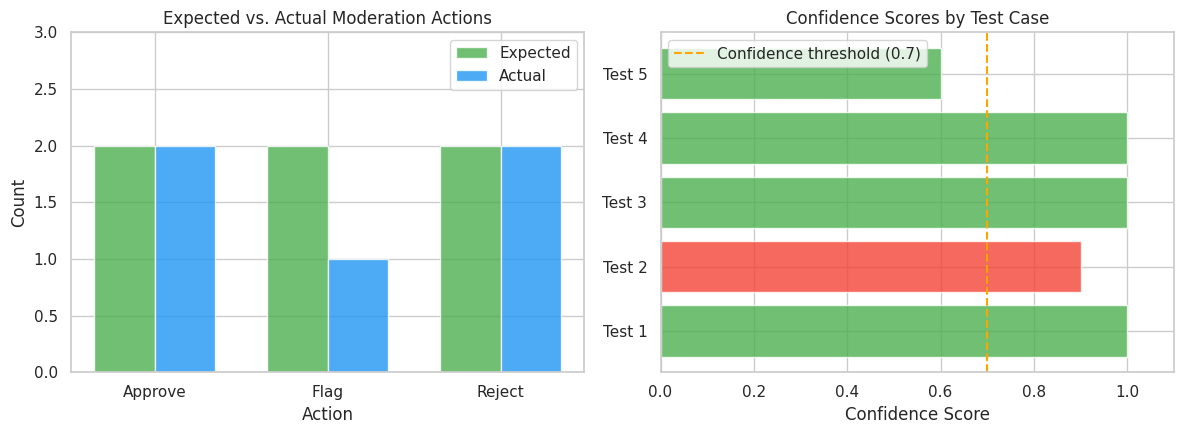

Results visualization saved.


In [10]:
# Visualize test results
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot 1: Expected vs Actual actions
actions = ["approve", "flag_for_review", "reject"]
expected_counts = []
actual_counts = []
for a in actions:
    expected_counts.append(sum(1 for r in results if a in r["expected"]))
    actual_counts.append(sum(1 for r in results if r["actual"] == a))

x = np.arange(len(actions))
width = 0.35
axes[0].bar(x - width/2, expected_counts, width, label="Expected", color="#4CAF50", alpha=0.8)
axes[0].bar(x + width/2, actual_counts, width, label="Actual", color="#2196F3", alpha=0.8)
axes[0].set_xlabel("Action")
axes[0].set_ylabel("Count")
axes[0].set_title("Expected vs. Actual Moderation Actions")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["Approve", "Flag", "Reject"])
axes[0].legend()
axes[0].set_ylim(0, 3)

# Plot 2: Confidence scores
test_names = [r["test_case"].split(":")[0] for r in results]
confidences = [r["confidence"] for r in results]
colors = ["#4CAF50" if (r["actual"] in r["expected"] or r["expected"] in r["actual"]) else "#F44336" for r in results]
axes[1].barh(test_names, confidences, color=colors, alpha=0.8)
axes[1].axvline(x=0.7, color="orange", linestyle="--", linewidth=1.5, label="Confidence threshold (0.7)")
axes[1].set_xlabel("Confidence Score")
axes[1].set_title("Confidence Scores by Test Case")
axes[1].legend()
axes[1].set_xlim(0, 1.1)

plt.tight_layout()
plt.savefig("results_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print("Results visualization saved.")

## Ethical Considerations

Content moderation systems raise several ethical concerns directly relevant to this agent.

**Over-classification and free expression.** Test Case 2 (borderline political debate) illustrates this tension directly: the agent rejected the content with high confidence (0.90), classifying it as a violence violation based on the word "hurt" used in a political context ("these policies hurt real families"). This is a clear over-classification — the word "hurt" was used metaphorically, not as a threat. When deployed at scale, such false positives suppress legitimate political speech. Automated moderation can silence users without adequate transparency or recourse (Gillespie, 2018), and the risk is particularly acute for political content where context and nuance are critical.

**Cultural and linguistic bias.** The keyword-based text analysis tool uses predefined English keyword lists that may not account for cultural variation in language use. Content from non-native speakers or speakers of minority dialects may be disproportionately flagged, a form of representational bias that can lead to unfair treatment of marginalized communities.

**Accountability.** When the agent makes a wrong decision — as it did on Test Case 2 — accountability is shared across the platform, engineers, policy writers, and the model provider. The decision logging in this system creates an audit trail, but meaningful accountability requires that users understand why their content was moderated and have a clear process for appeal.

**Over-reliance on automation.** Deploying automated moderation may reduce investment in human moderators, who bring contextual understanding and nuanced judgment that AI systems cannot replicate. The safeguards in this system (confidence threshold, high-severity override) are only effective if the platform commits to staffing adequate human review capacity.


### Failure Case Analysis

**Test Case 2 — Over-classification of political speech.** The most significant failure was on Test Case 2, where the agent rejected a borderline political debate post with 0.90 confidence, classifying it as a violence violation. The content used the word "hurt" metaphorically ("these policies hurt real families"), but the agent interpreted it as a threat. This demonstrates how keyword-triggered reasoning can misfire when the LLM lacks sufficient context to distinguish literal from figurative language. In a production system, this type of false positive would suppress legitimate political discourse.

**Test Case 5 — Coded language detection.** Test Case 5 was designed as an intentional edge case. The content uses coded language — euphemisms like "protect our neighborhood," "make them feel unwelcome," and "took over" — that conveys discriminatory intent without explicit slurs or threats. The agent flagged this for human review with low confidence (0.60), which is a reasonable outcome but reveals important limitations.

The agent detected the content partially: `analyze_text_patterns` found no keyword hits (no profanity, hate keywords, or threats matched), yet the agent still flagged it for hate_speech. This suggests the LLM recognized the implicit hostility through semantic understanding rather than the rule-based tool signals. However, the low confidence indicates the agent was uncertain about its own assessment.

These failure cases demonstrate two key limitations. First, the rule-based text analysis tool is insufficient for detecting nuanced violations because it relies on explicit keyword matching. Second, the agent can be overconfident when keywords trigger (Test 2, 0.90 confidence on a wrong decision) and underconfident when they do not (Test 5, 0.60 confidence on a correct decision). More sophisticated coded language — without the user history signal — would likely pass as approved, representing a false negative that could cause harm on a real platform.


## Architecture Diagram

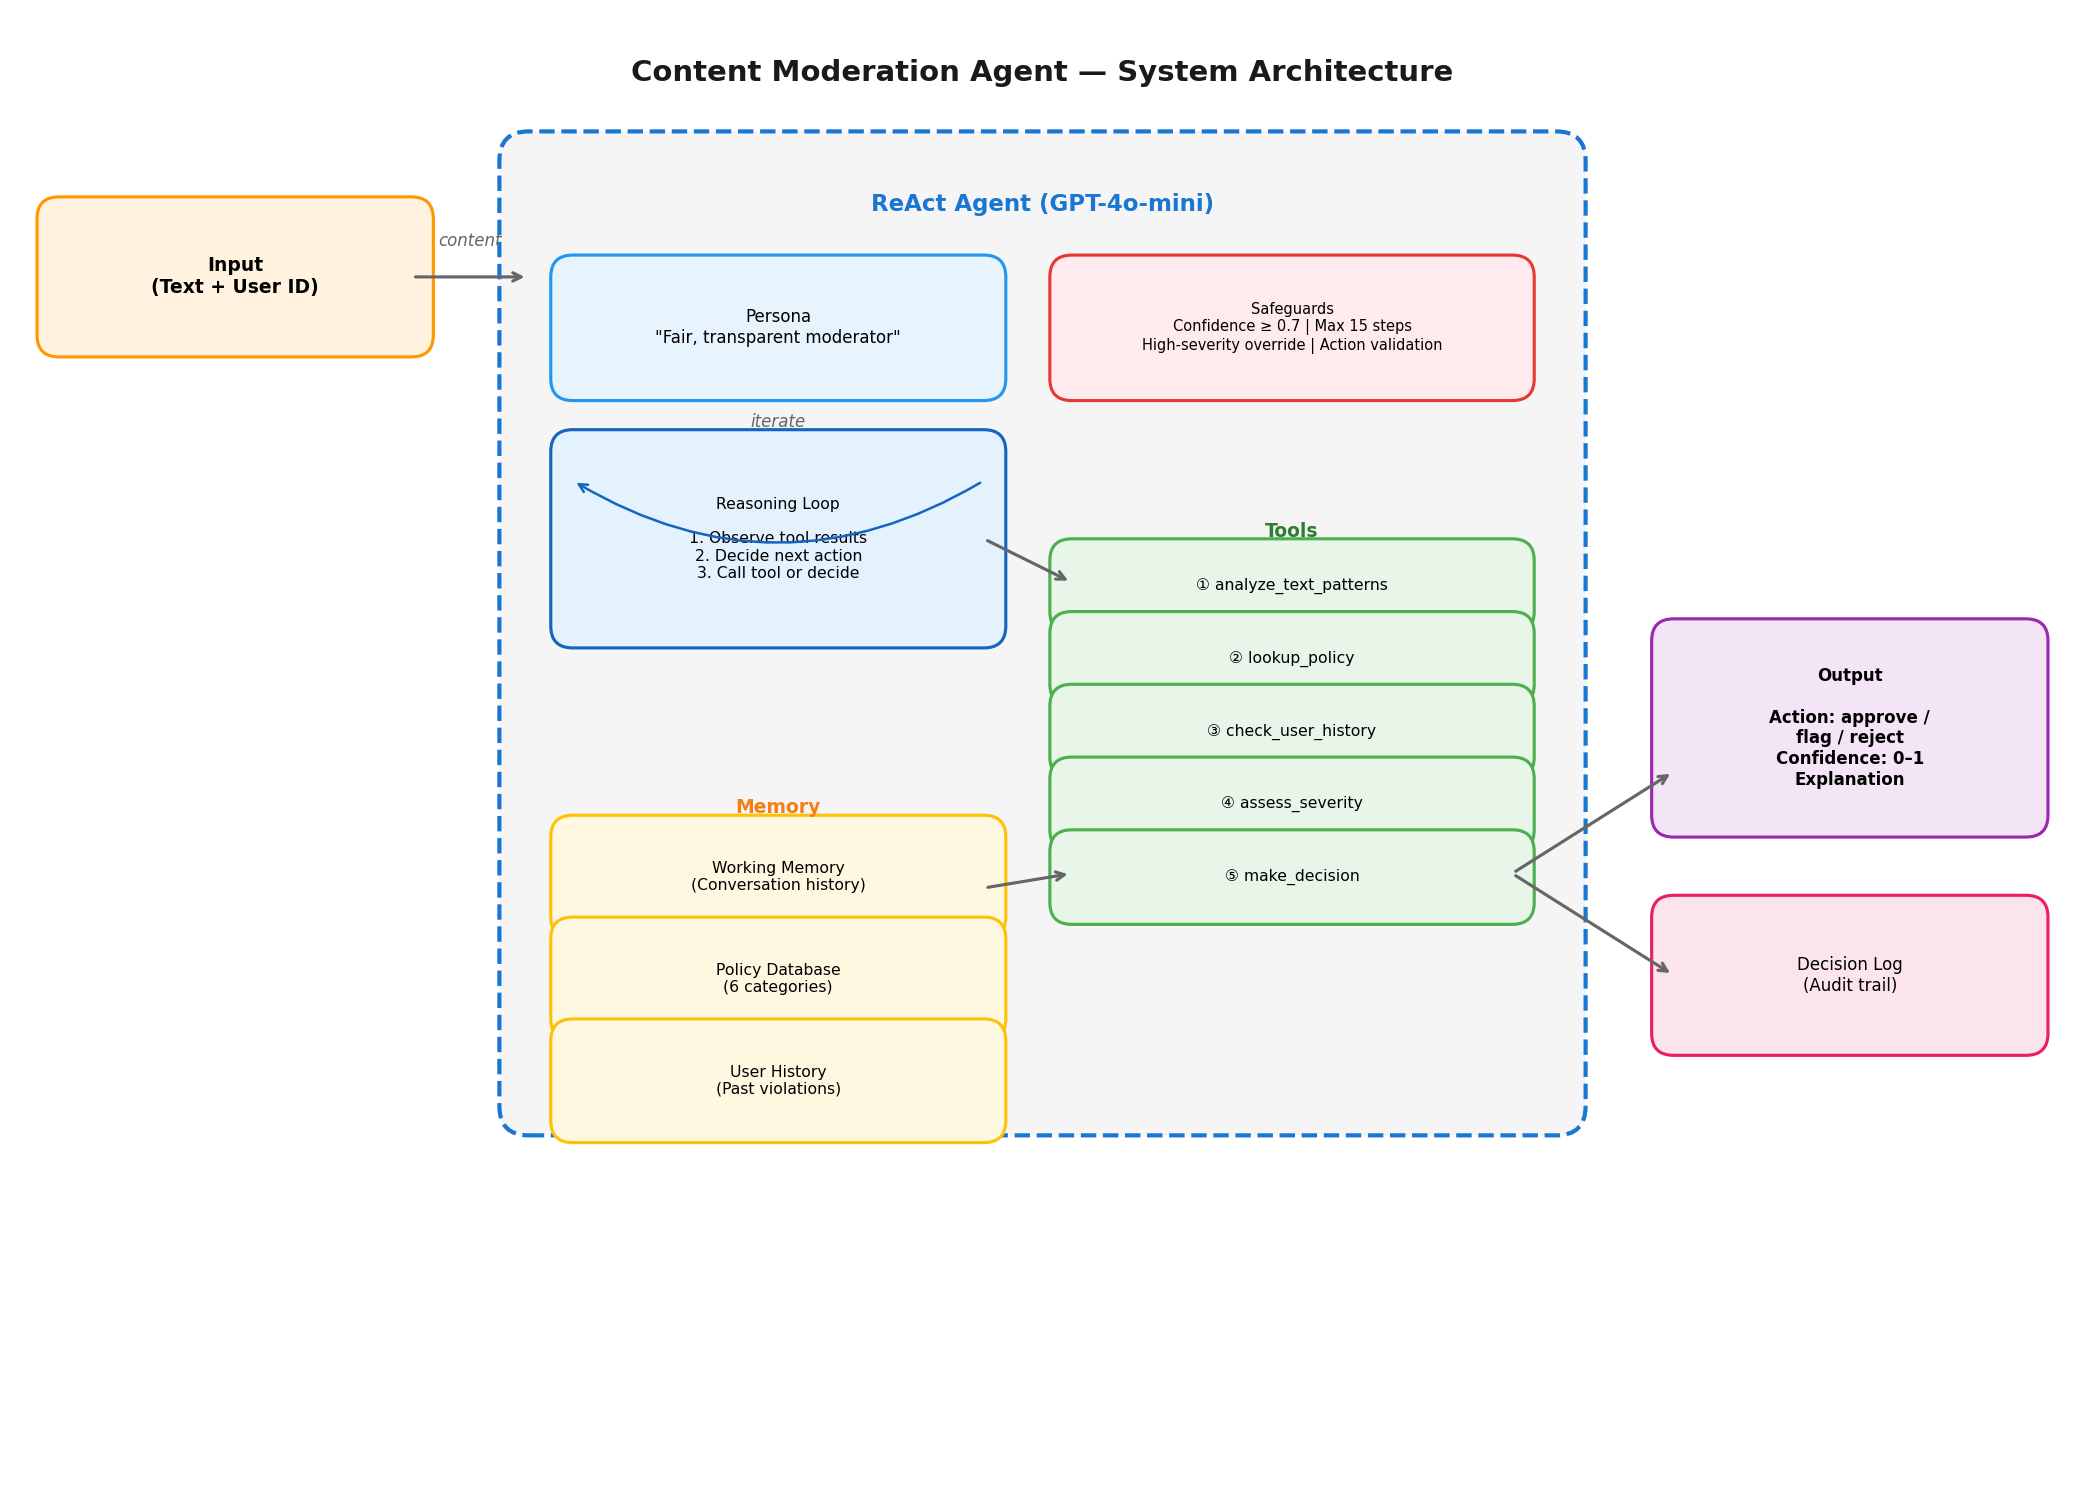

In [11]:
from IPython.display import Image, display
display(Image(filename="architecture_diagram.png"))

## Summary

This project implements a content moderation agent that analyzes user-generated text using a ReAct reasoning loop with OpenAI function calling. The agent uses five tools — text pattern analysis, policy lookup, user history checking, severity assessment, and decision recording — integrated through an iterative reasoning process where the LLM decides which tools to call based on intermediate results. Four safeguards (confidence threshold, iteration limit, high-severity override, and action constraints) ensure reliable moderation decisions. Testing across five scenarios showed that the agent correctly handles 4 out of 5 cases: rejecting clearly hateful content (Test 1), approving clean content including medical and news text (Tests 3–4), and flagging coded language for human review (Test 5). The most notable failure was Test Case 2, where the agent over-classified a borderline political debate as a violence violation due to the metaphorical use of the word "hurt," highlighting the risk of automated moderation suppressing legitimate speech. The main challenges observed were the agent's reliance on keyword signals that can misfire in context, and its inability to detect coded language through rule-based analysis alone — underscoring the importance of human oversight in automated content moderation.
